In [8]:
from torch_geometric.datasets import QM9

gap = QM9(root="./qm9_data").data.y[:, 4]
print(f"HOMO-LUMO gap: min={gap.min():.4f} eV, max={gap.max():.4f} eV, mean={gap.mean():.4f} eV")

HOMO-LUMO gap: min=0.6694 eV, max=16.9282 eV, mean=6.8585 eV


C:\Users\Viggo\AppData\Local\Temp\ipykernel_12684\540959575.py:3: UserWarning: It is not recommended to directly access the internal storage format `data` of an 'InMemoryDataset'. If you are absolutely certain what you are doing, access the internal storage via `InMemoryDataset._data` instead to suppress this warning. Alternatively, you can access stacked individual attributes of every graph via `dataset.{attr_name}`.
  gap = QM9(root="./qm9_data").data.y[:, 4]


In [2]:
import torch
from src.E3Model import Network

for l in [0, 1]:
    n = sum(p.numel() for p in Network(lmax=l).parameters() if p.requires_grad)
    print(f"l={l}: {n} trainable parameters")

l=0: 5988117 trainable parameters
l=1: 6043501 trainable parameters


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

SUBSETS = [10000]
LMAXES = [0, 1]

test_df = pd.read_csv("results/test.csv")
tests = {(l, s): test_df[(test_df.lmax == l) & (test_df.subset == s)]["test_mae_eV"].values
         for s in SUBSETS for l in LMAXES}

In [4]:
for s in SUBSETS:
    for l in LMAXES:
        x = tests[(l, s)]
        m, sd = x.mean(), x.std(ddof=1)
        ci = stats.t.ppf(0.975, len(x) - 1) * sd / np.sqrt(len(x))
        print(f"l={l} n={s}: mean={m:.4f} std={sd:.4f} ci=+/-{ci:.4f}")
        print(", ".join(f"{v:.4f}" for v in x))

l=0 n=10000: mean=0.1543 std=0.0027 ci=+/-0.0034
0.1510, 0.1541, 0.1544, 0.1535, 0.1585
l=1 n=10000: mean=0.1455 std=0.0018 ci=+/-0.0023
0.1436, 0.1482, 0.1449, 0.1443, 0.1464


In [5]:
def welch_df(a, b):
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    return (va + vb) ** 2 / (va ** 2 / (len(a) - 1) + vb ** 2 / (len(b) - 1))

for s in SUBSETS:
    x0, x1 = tests[(0, s)], tests[(1, s)]
    res = stats.ttest_ind(x1, x0, equal_var=False)
    print(f"n={s}: diff={x1.mean() - x0.mean():+.4f}  t={res.statistic:.3f}  df={welch_df(x1, x0):.1f}  p={res.pvalue:.2e}")

n=10000: diff=-0.0088  t=-6.040  df=7.0  p=5.10e-04


l=0 n=10000: Shapiro-Wilk W=0.9224 p=0.5455
l=1 n=10000: Shapiro-Wilk W=0.9417 p=0.6779


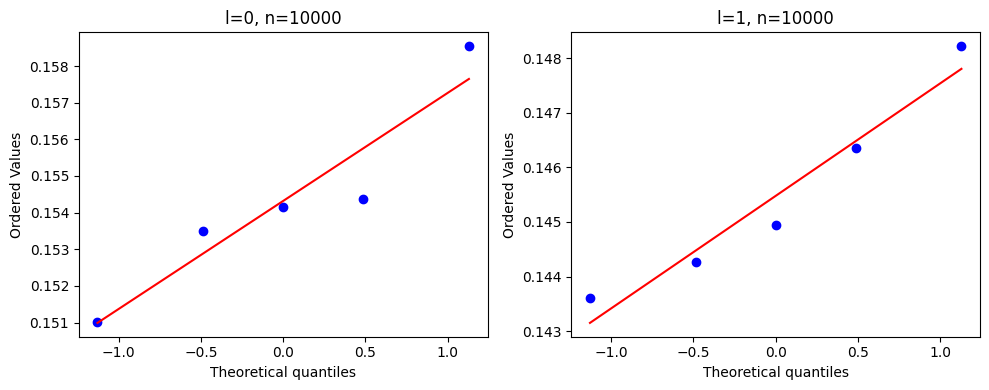

In [6]:
for s in SUBSETS:
    fig, axes = plt.subplots(1, len(LMAXES), figsize=(5 * len(LMAXES), 4))
    axes = np.atleast_1d(axes)
    for ax, l in zip(axes, LMAXES):
        x = tests[(l, s)]
        w, p = stats.shapiro(x)
        print(f"l={l} n={s}: Shapiro-Wilk W={w:.4f} p={p:.4f}")
        stats.probplot(x, dist="norm", plot=ax)
        ax.set_title(f"l={l}, n={s}")
    plt.tight_layout()
    plt.savefig(f"results/normality_n{s}.png", dpi=150, bbox_inches="tight")
    plt.show()

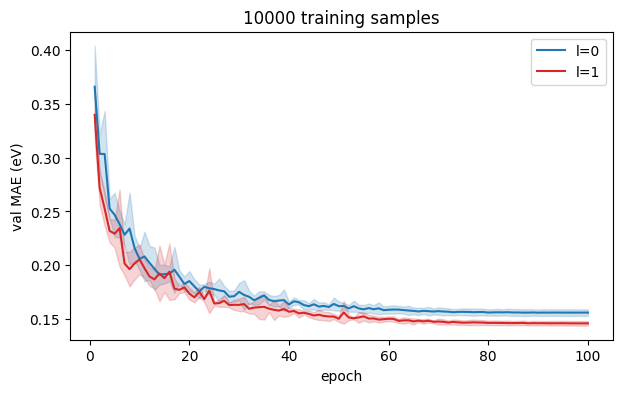

In [7]:
for s in SUBSETS:
    plt.figure(figsize=(7, 4))
    for l, c in [(0, "tab:blue"), (1, "tab:red")]:
        df = pd.read_csv(f"results/l{l}_n{s}.csv", encoding="utf-8-sig")
        g = df.groupby("epoch")["val_mae_eV"]
        n = df["seed"].nunique()
        ci = stats.t.ppf(0.975, n - 1) * g.std(ddof=1) / np.sqrt(n)
        plt.plot(g.mean().index, g.mean().values, color=c, label=f"l={l}")
        plt.fill_between(g.mean().index, g.mean() - ci, g.mean() + ci, color=c, alpha=0.2)
    plt.xlabel("epoch")
    plt.ylabel("val MAE (eV)")
    plt.title(f"{s} training samples")
    plt.legend()
    plt.savefig(f"results/val_curve_n{s}.png", dpi=150, bbox_inches="tight")
    plt.show()